In [1]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from examples.cmhe_demo_utils import * 
from metrics import treatment_effect
import matplotlib.pyplot as plt
from auton_survival import reporting
from matplotlib.pyplot import figure

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets_retrospective import load_allhat_lipid_dataset
outcomes, features, intervention, cat_feats, num_feats = load_allhat_lipid_dataset(location='/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/auton_survival/datasets/', outcome='CHD')

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:984: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1164: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'EP_CHD': outcomedt = 'DYCHD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1165: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'CANCER': outcomedt = 'DYCANC'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospective.py:1166: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif outcome is 'GIBLEED': outcomedt = 'DYGIBLD'
c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\datasets_retrospe

(10355, 20)
(24316, 1)


In [3]:
outcomes.time = outcomes.time / 365.25

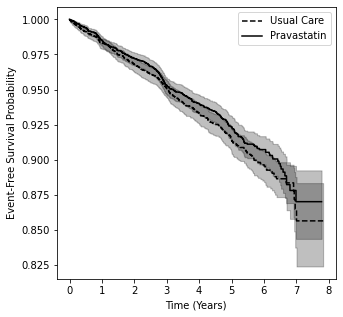

In [5]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_0 = reporting.plot_kaplanmeier(outcomes[intervention == 'Usual Care'], intervention[intervention == 'Usual Care'], color = 'black', linestyle = 'dashed')
ax_1 = reporting.plot_kaplanmeier(outcomes[intervention == 'Pravastatin'], intervention[intervention == 'Pravastatin'], color = 'black', linestyle = 'solid')
# h, l = ax_1.get_legend_handles_labels()
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
# plt.legend([h[0], h[1]], ['Pravastatin', 'Usual Care'], loc="upper right")
plt.savefig("ALLHAT.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [6]:
# Preprocess feature data
from preprocessing import Preprocessor
features_prep = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [7]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.
random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [8]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(features_prep, outcomes.time, outcomes.event, intervention=='Pravastatin', val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

100%|██████████| 100/100 [00:46<00:00,  2.17it/s]


In [9]:
zeta_probs = model.predict_latent_phi(features_prep)
zeta = np.argmax(zeta_probs, axis=1)

In [31]:
(features.Baseline_BMI)[zeta == 1].describe()

count    3244.000000
mean       29.849412
std         6.022865
min        14.555785
25%        25.871337
50%        28.957076
75%        33.072361
max        63.126435
Name: Baseline_BMI, dtype: float64

In [77]:
features.Baseline_Antihypertensive_Treatment.unique()

array(['On 1-2 drugs > 2 months', 'Currently untreated',
       'On drugs < 2 months'], dtype=object)

In [78]:
(features.Baseline_Antihypertensive_Treatment)[zeta == 1].value_counts()

On 1-2 drugs > 2 months    2698
Currently untreated         411
On drugs < 2 months         170
Name: Baseline_Antihypertensive_Treatment, dtype: int64

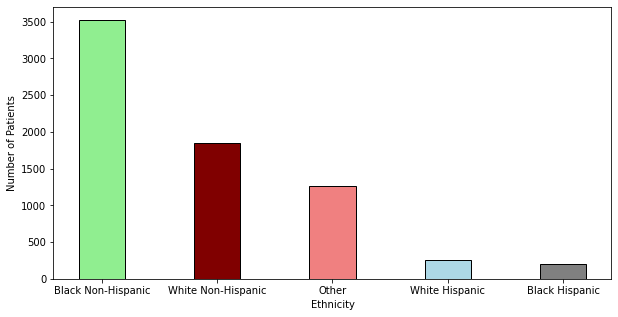

In [76]:
# Plot distribution of patients by Smoke Status
plt.figure(figsize=(10,5))
plt.bar(['Black Non-Hispanic', 'White Non-Hispanic', 'Other', 'White Hispanic', 'Black Hispanic'], features[zeta == 0].Ethnicity.value_counts(), color = ['lightgreen', 'maroon', 'lightcoral', 'lightblue', 'grey'],
        width = 0.4, edgecolor='black')
plt.xlabel("Ethnicity")
plt.ylabel("Number of Patients")
plt.savefig("ALLHAT ben ethn.pdf", format='pdf', bbox_inches='tight')
# plt.title("Distribution of Patients in Zeta 0 by Smoke Status at Baseline")
plt.show()

In [9]:
(zeta == 0).sum()

7076

In [10]:
(zeta == 1).sum()

3279

In [11]:
outcomes[zeta == 0].event.sum() / sum(outcomes.event)

0.6429463171036205

In [12]:
outcomes[zeta == 1].event.sum() / sum(outcomes.event)

0.3570536828963795

In [14]:
hr = treatment_effect('hazard_ratio', outcomes, intervention == 'Pravastatin', n_bootstrap=100)
CI = np.quantile(hr, [0.025, 0.975])
print(CI)
print(sum(hr)/len(hr))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.79662702 1.00578739]
0.8907014667235057


In [10]:
hr_zeta0 = treatment_effect('hazard_ratio', outcomes[zeta == 0], intervention[zeta == 0] == 'Pravastatin', n_bootstrap=100)
CI_zeta0 = np.quantile(hr_zeta0, [0.025, 0.975])
print(CI_zeta0)
print(sum(hr_zeta0)/len(hr_zeta0))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.98411616 1.41532356]
1.191811508862985


In [11]:
hr_zeta1 = treatment_effect('hazard_ratio', outcomes[zeta == 1], intervention[zeta == 1] == 'Pravastatin', n_bootstrap=100)
CI_zeta1 = np.quantile(hr_zeta1, [0.025, 0.975])
print(CI_zeta1)
print(sum(hr_zeta1)/len(hr_zeta1))

c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\metrics.py:107: UserWarning: WARNING: You are computing Hazard Ratios.
 Make sure you have tested the PH Assumptions.
  warnings.warn("WARNING: You are computing Hazard Ratios.\n Make sure you have tested the PH Assumptions.")


Bootstrapping...  100  number of times. This may take a while. Please be Patient...
[0.44041549 0.69005385]
0.5402506787655974


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16976\1272031581.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_2 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Pravastatin'], intervention[zeta==0][intervention == 'Pravastatin'], color = 'black', linestyle = 'solid')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16976\1272031581.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_3 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Usual Care'], intervention[zeta==0][intervention == 'Usual Care'], color = 'black', linestyle = 'dashed')


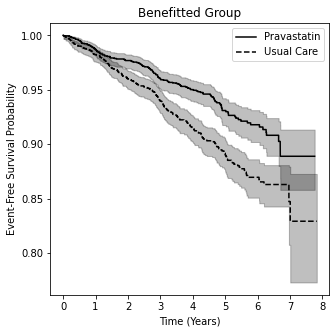

In [12]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_2 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Pravastatin'], intervention[zeta==0][intervention == 'Pravastatin'], color = 'black', linestyle = 'solid')
ax_3 = reporting.plot_kaplanmeier(outcomes[zeta==0][intervention == 'Usual Care'], intervention[zeta==0][intervention == 'Usual Care'], color = 'black', linestyle = 'dashed')
plt.title('Benefitted Group')
# h, l = ax_0.get_legend_handles_labels()
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
# plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.savefig("ALLHAT benefitted.pdf", format='pdf', bbox_inches='tight')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16976\3262868154.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_4 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Pravastatin'], intervention[zeta==1][intervention == 'Pravastatin'], color = 'black', linestyle = 'solid')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_16976\3262868154.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ax_5 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Usual Care'], intervention[zeta==1][intervention == 'Usual Care'], color = 'black', linestyle = 'dashed')


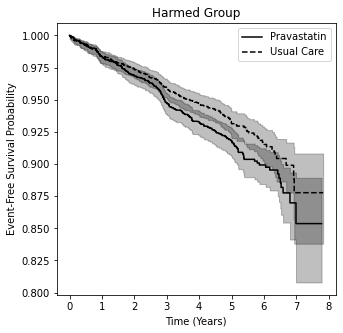

In [13]:
# Let's plot the survival curves in the original paper
figure(figsize=(5,5))
ax_4 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Pravastatin'], intervention[zeta==1][intervention == 'Pravastatin'], color = 'black', linestyle = 'solid')
ax_5 = reporting.plot_kaplanmeier(outcomes[zeta==1][intervention == 'Usual Care'], intervention[zeta==1][intervention == 'Usual Care'], color = 'black', linestyle = 'dashed')
plt.title('Harmed Group')
# h, l = ax_0.get_legend_handles_labels()
plt.xlabel('Time (Years)')
plt.ylabel('Event-Free Survival Probability')
# plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.savefig("ALLHAT harmed.pdf", format='pdf', bbox_inches='tight')
plt.show()

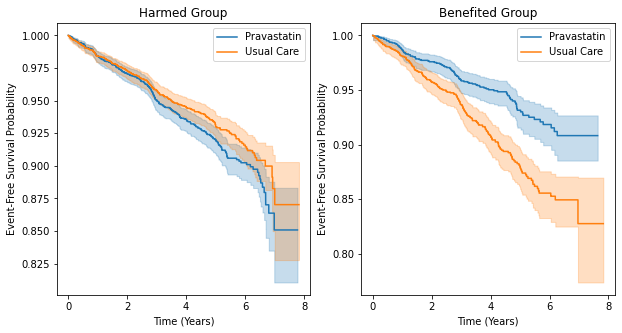

In [20]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
ax1.set_title('Harmed Group')
ax2.set_title('Benefited Group')
for ax in fig.get_axes():
    # ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Years)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Pravastatin', 'Usual Care'], loc="upper right")
plt.savefig("ALLHAT pheno.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [13]:
from sklearn import tree # Import the decision tree namespace
from sklearn.metrics import plot_confusion_matrix # Generate a confusion matrix

In [14]:
# Get the numerical features
cols_to_use2 = features.columns.difference(features_prep.columns)
feat_num = features.loc[:, ~features.columns.isin(cols_to_use2)]
feat_num

,Baseline_HDL_Cholesterol,Baseline_Height_INC,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Age,Baseline_Weight_LBS,Baseline_Total_Cholesterol,Baseline_Triglycerides,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_LDL_Cholesterol,Baseline_BMI,Baseline_Glucose
STUDYID,,,,,,,,,,,
1.0,38.5,71.0,151.0,67.0,160.0,204.5,84.5,92.0,149.0,22.360643,86.0
33.0,31.0,67.0,146.0,55.0,211.0,243.0,140.0,94.0,184.0,33.114168,84.0
87.0,48.5,71.0,137.0,72.0,187.0,258.0,201.5,85.0,169.0,26.134001,332.0
88.0,53.0,NaN,162.0,59.0,141.0,229.5,NaN,110.0,143.5,NaN,NaN
92.0,57.0,69.0,140.0,75.0,184.0,222.0,75.0,90.0,150.0,27.227053,107.0
...,...,...,...,...,...,...,...,...,...,...,...
199839.0,46.5,62.0,135.0,59.0,161.0,216.0,303.5,71.0,109.0,29.506894,101.0
199844.0,45.0,64.0,113.0,59.0,152.0,217.0,NaN,75.0,156.0,26.143555,NaN
199881.0,54.0,70.0,151.0,74.0,161.0,180.0,82.0,65.0,110.0,23.147857,79.0


In [15]:
# Get the categorical features
cols_to_use = features_prep.columns.difference(features.columns)
feat_cat = features_prep[cols_to_use]
feat_cat

,Baseline_Antihypertensive_Treatment_On 1-2 drugs > 2 months,Baseline_Antihypertensive_Treatment_On drugs < 2 months,Baseline_Estrogen_Supplementation_No,Baseline_Estrogen_Supplementation_Yes,Baseline_History_Aspirin_No,Baseline_History_Aspirin_Yes,Baseline_History_Congenital_Heart_Defects_Yes,Baseline_History_Diabetes_Yes,Baseline_Smoke_status_Never,Baseline_Smoke_status_Past,Ethnicity_Black Non-Hispanic,Ethnicity_Other,Ethnicity_White Hispanic,Ethnicity_White Non-Hispanic,Sex_Male
STUDYID,,,,,,,,,,,,,,,
1.0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1
33.0,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0
87.0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,1
88.0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0
92.0,1,0,0,0,1,0,0,1,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199839.0,1,0,1,0,0,1,1,0,0,1,0,1,0,0,0
199844.0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0
199881.0,1,0,0,0,0,1,1,0,0,1,0,1,0,0,1


In [16]:
# Get the features to train Decision Tree Classifier
features_dt = pd.merge(feat_cat, feat_num, left_index=True, right_index=True, how='inner')
features_dt

,Baseline_Antihypertensive_Treatment_On 1-2 drugs > 2 months,Baseline_Antihypertensive_Treatment_On drugs < 2 months,Baseline_Estrogen_Supplementation_No,Baseline_Estrogen_Supplementation_Yes,Baseline_History_Aspirin_No,Baseline_History_Aspirin_Yes,Baseline_History_Congenital_Heart_Defects_Yes,Baseline_History_Diabetes_Yes,Baseline_Smoke_status_Never,Baseline_Smoke_status_Past,...,Baseline_Height_INC,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Age,Baseline_Weight_LBS,Baseline_Total_Cholesterol,Baseline_Triglycerides,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_LDL_Cholesterol,Baseline_BMI,Baseline_Glucose
STUDYID,,,,,,,,,,,,,,,,,,,,,
1.0,1,0,0,0,1,0,0,0,0,0,...,71.0,151.0,67.0,160.0,204.5,84.5,92.0,149.0,22.360643,86.0
33.0,1,0,0,1,1,0,0,0,0,0,...,67.0,146.0,55.0,211.0,243.0,140.0,94.0,184.0,33.114168,84.0
87.0,1,0,0,0,1,0,0,1,1,0,...,71.0,137.0,72.0,187.0,258.0,201.5,85.0,169.0,26.134001,332.0
88.0,0,0,1,0,1,0,0,0,1,0,...,NaN,162.0,59.0,141.0,229.5,NaN,110.0,143.5,NaN,NaN
92.0,1,0,0,0,1,0,0,1,1,0,...,69.0,140.0,75.0,184.0,222.0,75.0,90.0,150.0,27.227053,107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199839.0,1,0,1,0,0,1,1,0,0,1,...,62.0,135.0,59.0,161.0,216.0,303.5,71.0,109.0,29.506894,101.0
199844.0,1,0,1,0,0,1,0,0,0,0,...,64.0,113.0,59.0,152.0,217.0,NaN,75.0,156.0,26.143555,NaN
199881.0,1,0,0,0,0,1,1,0,0,1,...,70.0,151.0,74.0,161.0,180.0,82.0,65.0,110.0,23.147857,79.0


In [17]:
from sklearn.model_selection import train_test_split

# Split the data into training and test data
x_train, x_test, y_train, y_test = train_test_split(features_dt, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Pravastatin'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 7248
Number of test data points: 3107


In [18]:
# Get the Zeta for Train data
idxs = x_train.dropna(axis=0).index.values.astype(int)
f_idxs = features_prep.index.values.astype(int)
mask = np.in1d(f_idxs, idxs)

# Get the Zeta for Test data
idxs2 = x_test.dropna(axis=0).index.values.astype(int)
f_idxs2 = features_prep.index.values.astype(int)
mask2 = np.in1d(f_idxs2, idxs2)

In [19]:
# Create and fit the model using entropy separation and a maximum depth
# Drop NaNs because the feature columns not preprocessed i.e. 
# Numerical features have NaNs 
dt_model = tree.DecisionTreeClassifier(criterion='entropy', max_depth=4)
dt_model.fit(x_train.dropna(axis=0), zeta[mask])

DecisionTreeClassifier(criterion='entropy', max_depth=4)

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


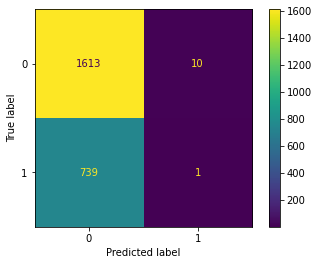

In [20]:
# Plot the confusion matrix
plot_confusion_matrix(dt_model, x_test.dropna(axis = 0), zeta[mask2], values_format='d', labels=[0, 1])

In [21]:
# Get the accuracy of test and train data
from sklearn.model_selection import cross_validate
scoring = ['accuracy','precision', 'recall', 'f1']
scores = cross_validate(dt_model, x_train.dropna(axis = 0), zeta[mask], scoring=scoring, return_train_score=True, cv=5)
results = pd.DataFrame(scores)
results.mean()

fit_time           0.018408
score_time         0.005656
test_accuracy      0.684532
train_accuracy     0.696990
test_precision     0.213000
train_precision    0.749067
test_recall        0.004655
train_recall       0.021539
test_f1            0.008943
train_f1           0.041450
dtype: float64

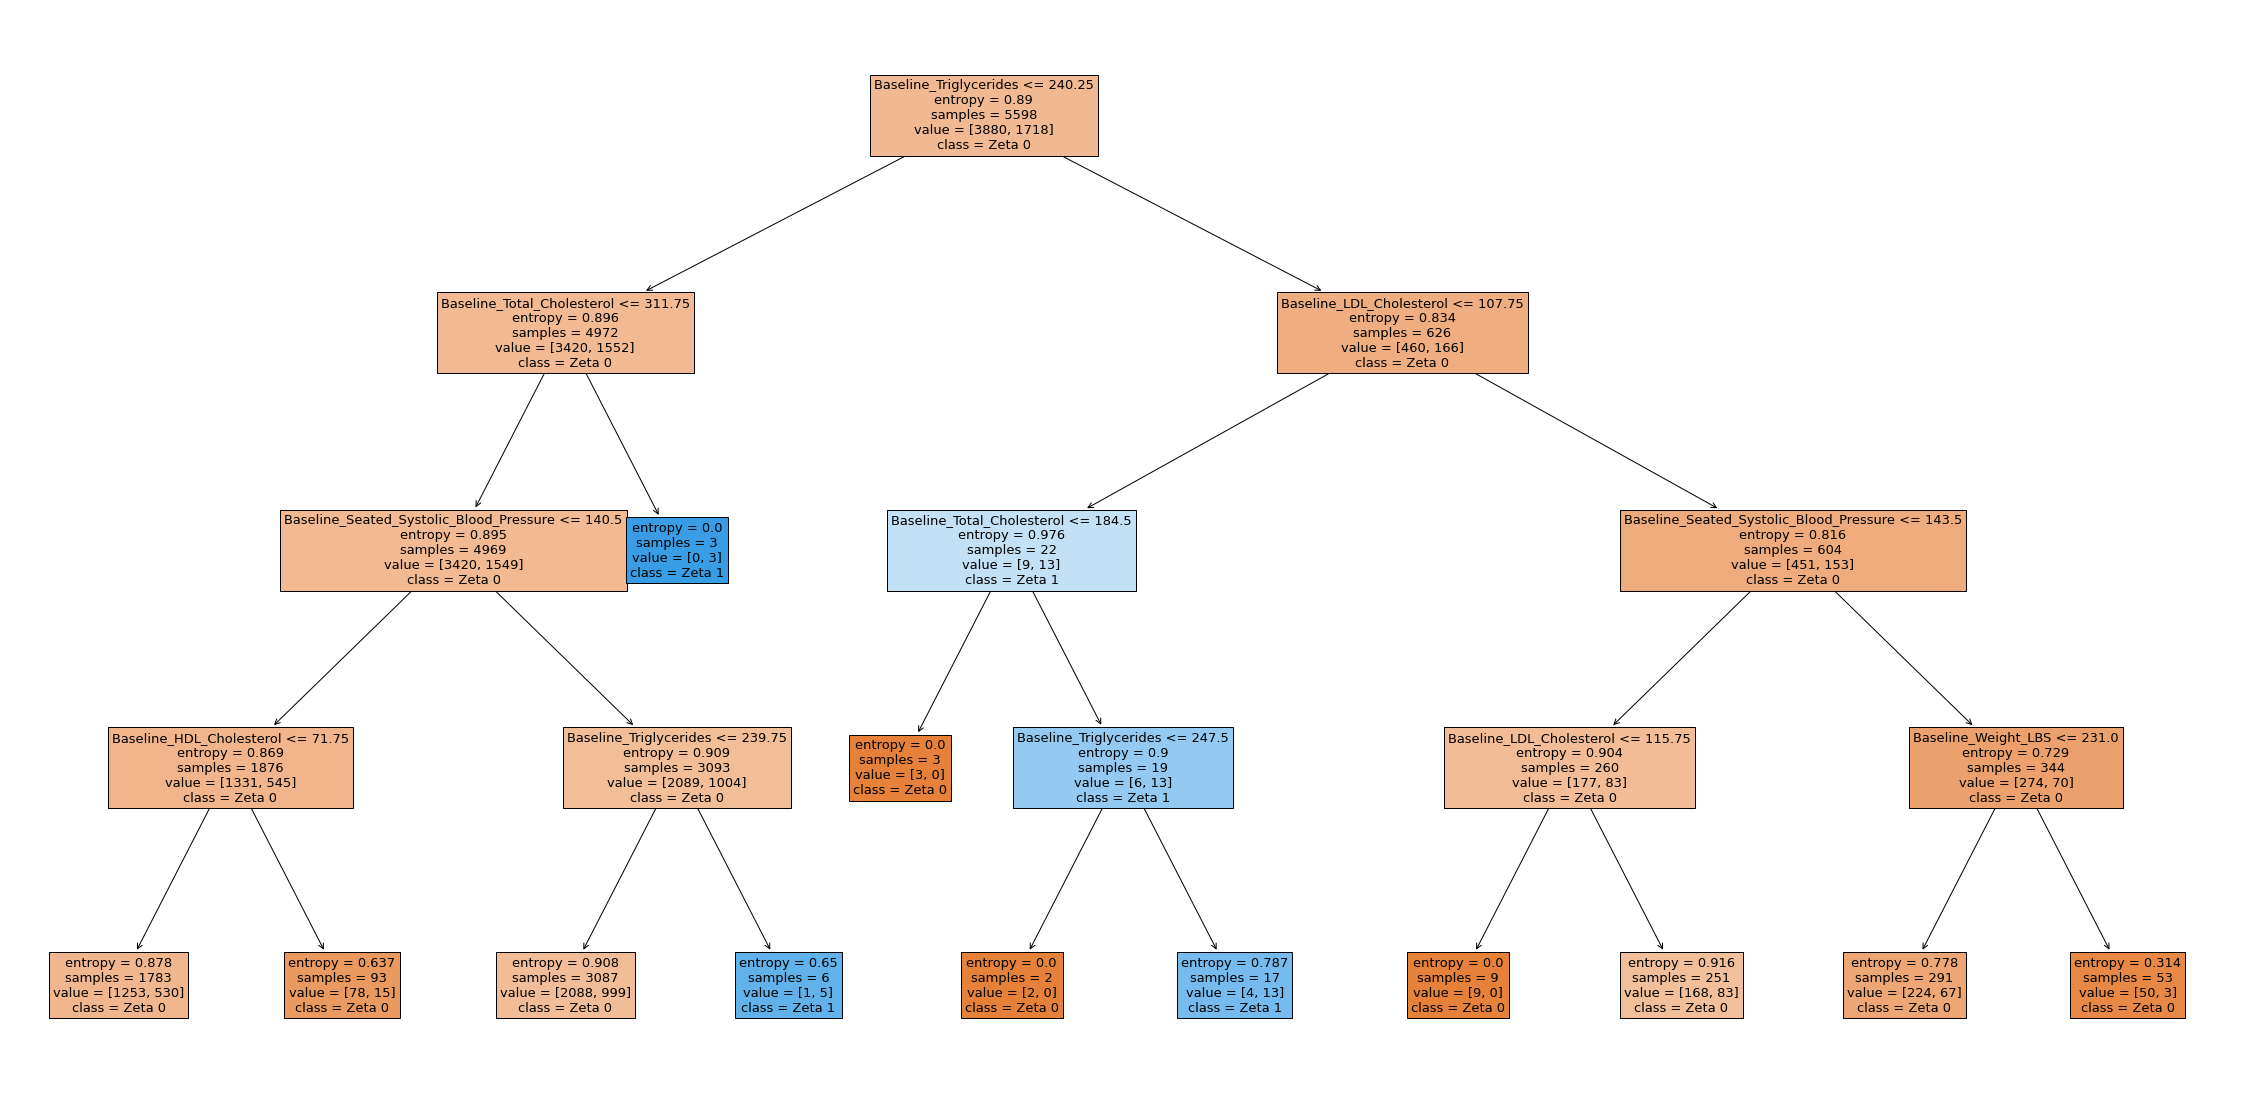

In [27]:
# Let's check out the tree
plt.figure(figsize=(40,20))
tree.plot_tree(dt_model, feature_names=features_dt.columns, class_names=['Zeta 0', 'Zeta 1'], fontsize=13, filled=True)
plt.show()